In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

from sklearn.linear_model import LinearRegression

import warnings
warnings.filterwarnings("ignore")
sns.set_style("whitegrid")

# Read the data and the basic analysis

In [3]:
df = pd.read_csv("insurance.csv")
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [4]:
print("Shape:", df.shape)

Shape: (1338, 7)


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


In [6]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [7]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [8]:
#check for duplicates
df.duplicated().sum()

np.int64(1)

In [9]:
df.drop_duplicates(inplace=True)

# statrt EDA

In [10]:
num_cols = ['age', 'bmi', 'children', 'charges']

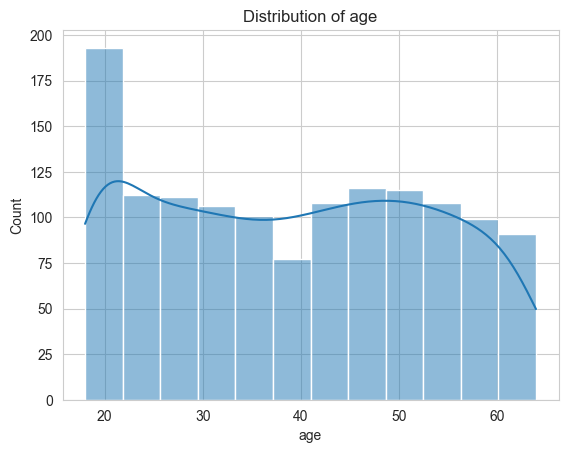

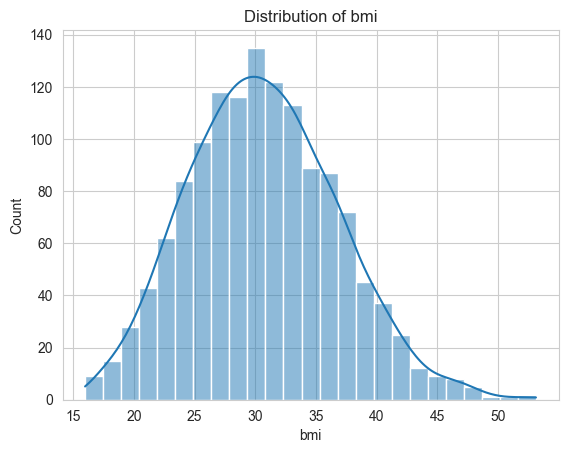

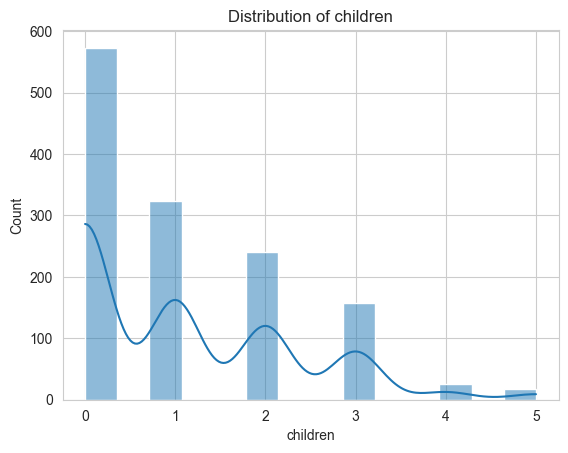

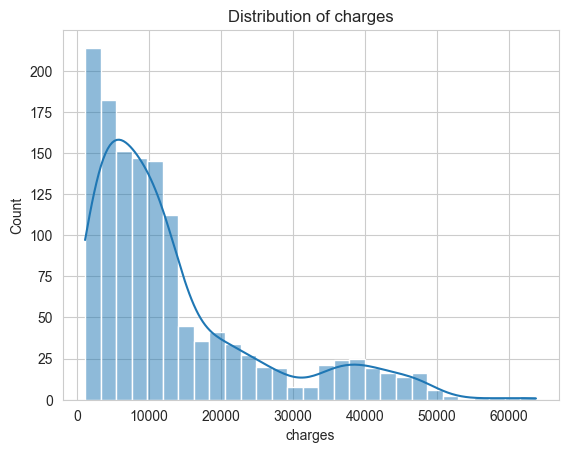

In [11]:
for col in num_cols:
    plt.figure()
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()

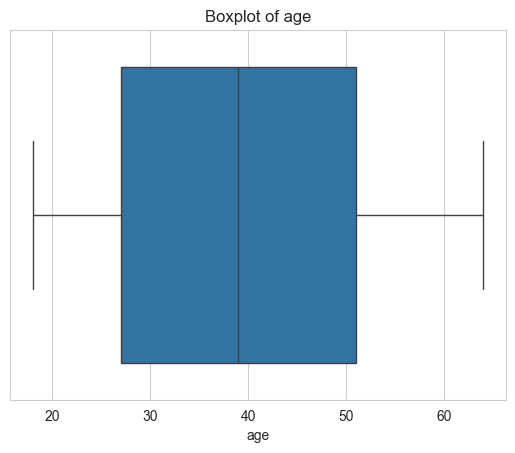

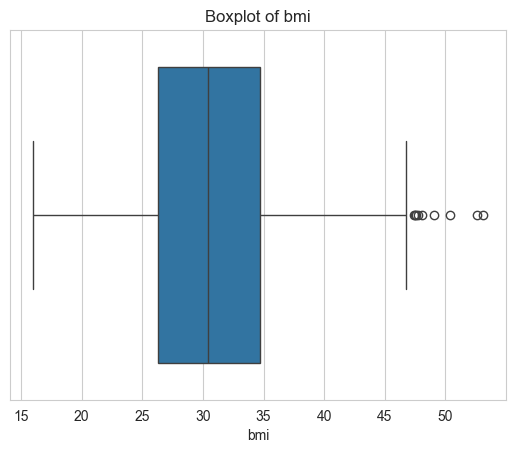

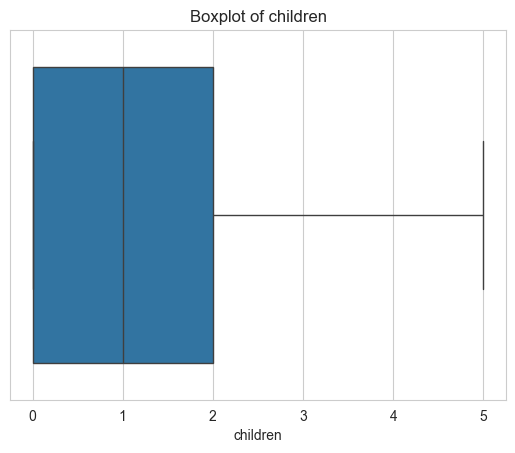

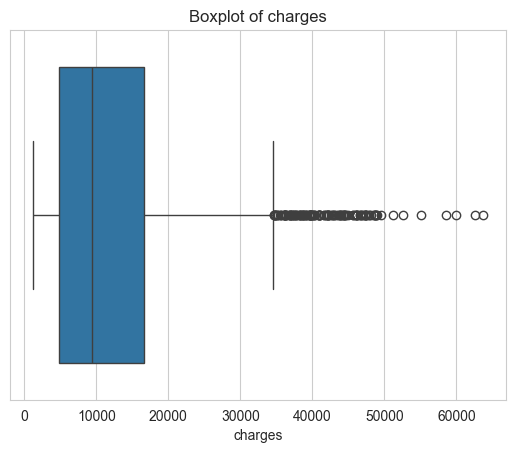

In [12]:
for col in num_cols:
    plt.figure()
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

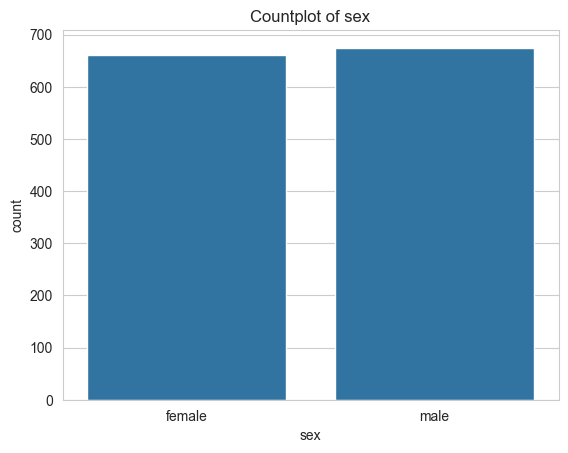

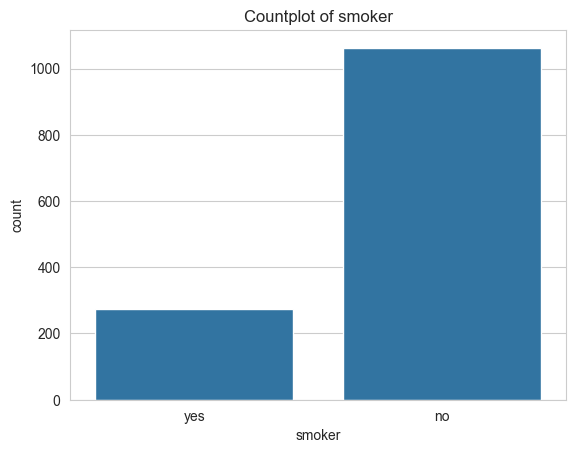

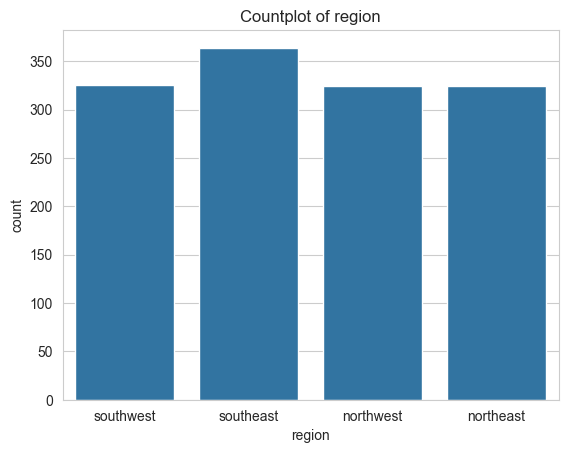

In [13]:
cat_cols = ['sex', 'smoker', 'region']

for col in cat_cols:
    plt.figure()
    sns.countplot(x=df[col])
    plt.title(f"Countplot of {col}")
    plt.show()

# Bivariate Analysis

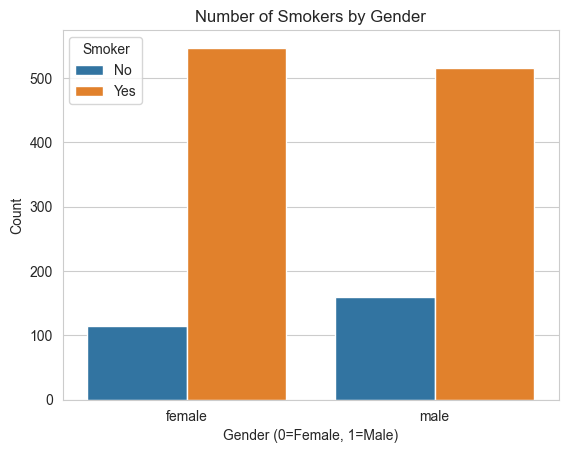

In [14]:
# Count plot for number of smokers by gender
sns.countplot(x='sex', hue='smoker', data=df)
plt.title('Number of Smokers by Gender')
plt.xlabel('Gender (0=Female, 1=Male)')
plt.ylabel('Count')
plt.legend(title='Smoker', labels=['No', 'Yes'])
plt.show()

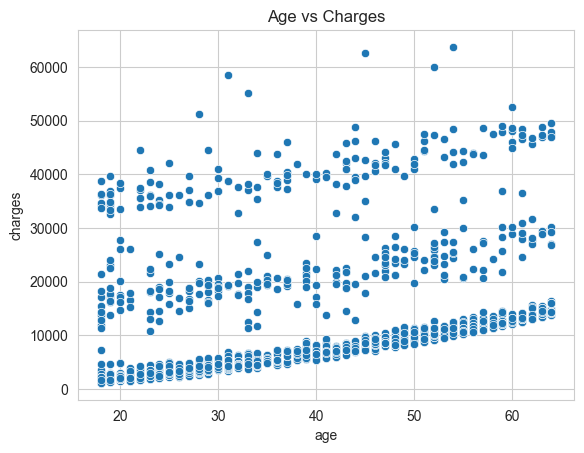

In [15]:
# Age vs Charges
sns.scatterplot(x='age', y='charges', data=df)
plt.title("Age vs Charges")
plt.show()

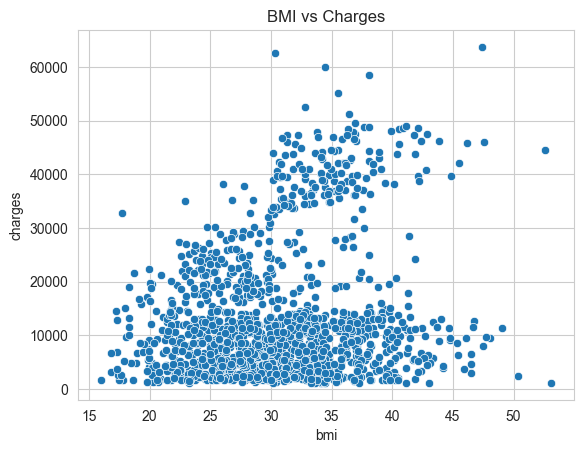

In [16]:
# BMI vs Charges
sns.scatterplot(x='bmi', y='charges', data=df)
plt.title("BMI vs Charges")
plt.show()

In [17]:
df.groupby('smoker')['charges'].mean().sort_values(ascending=False)

smoker
yes    32050.231832
no      8440.660307
Name: charges, dtype: float64

In [18]:
df.groupby('sex')['charges'].mean().sort_values(ascending=False)

sex
male      13974.998864
female    12569.578844
Name: charges, dtype: float64

In [19]:
pd.crosstab(df['region'], df['smoker'])

smoker,no,yes
region,,
northeast,257,67
northwest,266,58
southeast,273,91
southwest,267,58


In [20]:
df.groupby('region')['charges'].mean().sort_values(ascending=False)

region
southeast    14735.411438
northeast    13406.384516
northwest    12450.840844
southwest    12346.937377
Name: charges, dtype: float64

In [21]:
pd.crosstab(df['sex'], df['smoker'])

smoker,no,yes
sex,,
female,547,115
male,516,159


In [22]:
df.groupby('sex')['charges'].sum().sort_values(ascending=False)

sex
male      9.433124e+06
female    8.321061e+06
Name: charges, dtype: float64

In [23]:
pd.crosstab(df['children'], df['smoker'])

smoker,no,yes
children,,
0,458,115
1,263,61
2,185,55
3,118,39
4,22,3
5,17,1


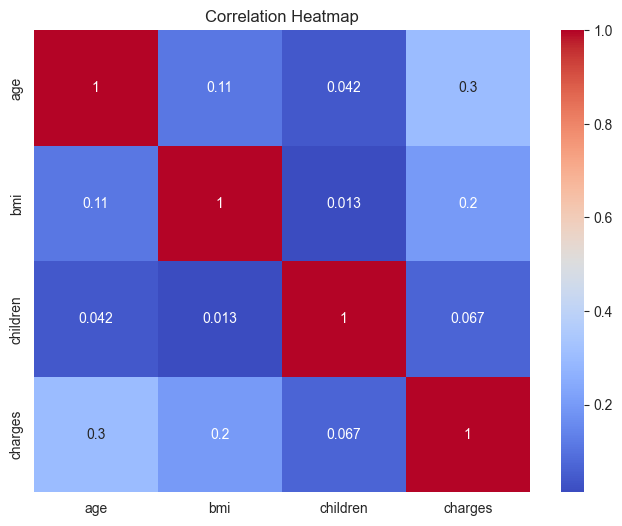

In [24]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

# apply

In [25]:
le = LabelEncoder()

df['sex'] = le.fit_transform(df['sex'])
df['smoker'] = le.fit_transform(df['smoker'])
df['region'] = le.fit_transform(df['region'])
df['charges_log']=np.log(df['charges'])
df.head()

,age,sex,bmi,children,smoker,region,charges,charges_log
0,19,0,27.900,0,1,3,16884.92400,9.734176
1,18,1,33.770,1,0,2,1725.55230,7.453302
2,28,1,33.000,3,0,2,4449.46200,8.400538
3,33,1,22.705,0,0,1,21984.47061,9.998092
4,32,1,28.880,0,0,1,3866.85520,8.260197


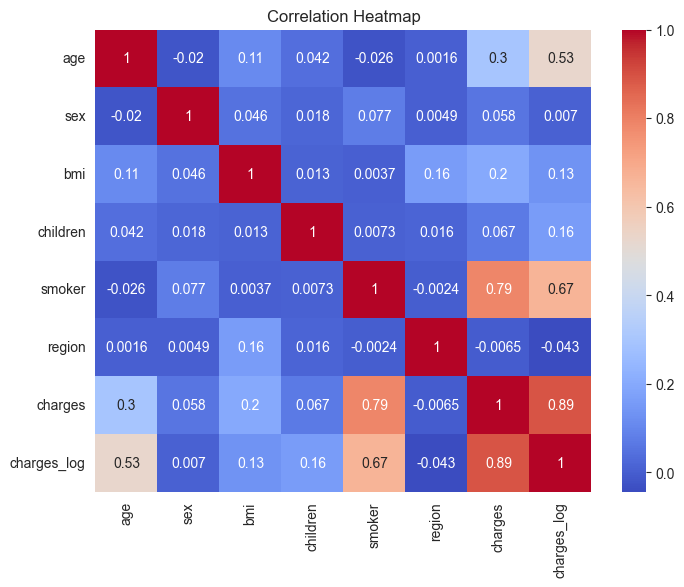

In [26]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

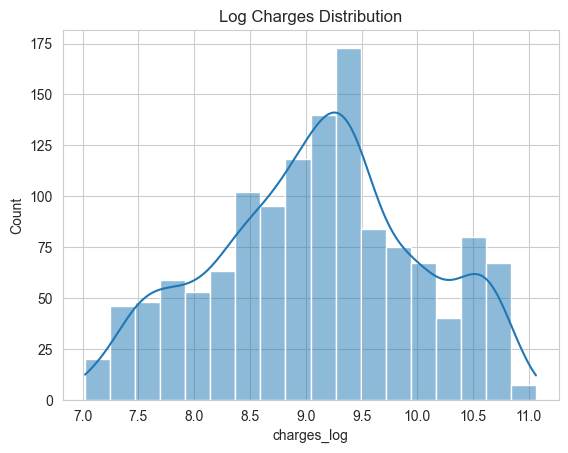

In [27]:
sns.histplot(df['charges_log'], kde=True)
plt.title("Log Charges Distribution")
plt.show()

In [28]:
X = df.drop(['charges', 'charges_log'], axis=1)
y = df['charges_log']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [29]:
# normalize the data 
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [30]:
model = LinearRegression()

In [31]:
model.fit(X_train_scaled, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [32]:
y_pred = model.predict(X_test_scaled)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

In [33]:
print(f"Mean Squared Error: {mse}")
print(f"R^2 Score: {r2}")

Mean Squared Error: 0.159862370096802
R^2 Score: 0.8277679326642478


# Feature Engineering

In [34]:
df=pd.read_csv("insurance.csv")

In [35]:
newdf=df.copy()
newdf.drop_duplicates(inplace=True)

In [36]:
newdf['bmi_deviation'] = abs(newdf['bmi'] - 22)

newdf['smoker'] = newdf['smoker'].map({'yes':1, 'no':0})

newdf['smoker_intensity'] = newdf['smoker'] * newdf ['age']

newdf['health_index'] = (
    newdf['bmi'] * 0.3 +
    newdf['age'] * 0.5 +
    newdf['smoker'] * 30
)

newdf['high_risk'] = (
    (newdf['smoker'] == 1) &
    (newdf['bmi'] > 30) &
    (newdf['age'] > 50)
).astype(int)

newdf['age_bmi_smoker'] = newdf['age'] * newdf['bmi'] * newdf['smoker']
newdf.head()

,age,sex,bmi,children,smoker,region,charges,bmi_deviation,smoker_intensity,health_index,high_risk,age_bmi_smoker
0,19,female,27.900,0,1,southwest,16884.92400,5.900,19,47.8700,0,530.1
1,18,male,33.770,1,0,southeast,1725.55230,11.770,0,19.1310,0,0.0
2,28,male,33.000,3,0,southeast,4449.46200,11.000,0,23.9000,0,0.0
3,33,male,22.705,0,0,northwest,21984.47061,0.705,0,23.3115,0,0.0
4,32,male,28.880,0,0,northwest,3866.85520,6.880,0,24.6640,0,0.0


In [37]:
newdf['charges']=np.log(newdf['charges'])

In [38]:
newdf['sex']=newdf['sex'].map({'male':1, 'female':0})
newdf['region']=newdf['region'].map({'southeast':0, 'southwest':1, 'northeast':2, 'northwest':3})

In [39]:
# the colloraiton between the new features and the target variable
correlation = newdf.corr(numeric_only=True)['charges'].sort_values(ascending=False)
print(correlation)

charges             1.000000
health_index        0.853283
smoker              0.665718
age_bmi_smoker      0.655717
smoker_intensity    0.643718
age                 0.526927
high_risk           0.309624
children            0.160336
bmi                 0.132822
bmi_deviation       0.122175
sex                 0.007009
region             -0.001518
Name: charges, dtype: float64


In [40]:
X=newdf.drop(['charges',], axis=1)
y=newdf['charges']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"Mean Squared Error: {mse}")
print(f"R^2 Score: {r2}")


Mean Squared Error: 0.12859272441877748
R^2 Score: 0.861457134924426


In [ ]:
import pickle

pickle.dump(model, open("model.pkl", "wb"))

pickle.dump(scaler, open("scaler.pkl", "wb"))

print("saved model & scaler")


saved model & scaler
